In [111]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [107]:
data = [
    ['36-55', "Master's",     'High', 'Single',  'Yes'],
    ['18-35', 'High School',  'Low',  'Single',  'No'],
    ['36-55', "Master's",     'Low',  'Single',  'Yes'],
    ['18-35', "Bachelor's",   'High', 'Single',  'No'],
    ['<18',   'High School',  'Low',  'Single',  'Yes'],
    ['18-35', "Bachelor's",   'High', 'Married', 'No'],
    ['36-55', "Bachelor's",   'Low',  'Married', 'No'],
    ['>55',   "Bachelor's",   'High', 'Single',  'Yes'],
    ['36-55', "Master's",     'Low',  'Married', 'No'],
    ['>55',   "Master's",     'Low',  'Married', 'Yes'],
    ['36-55', "Master's",     'High', 'Single',  'Yes'],
    ['>55',   "Master's",     'High', 'Single',  'Yes'],
    ['<18',   'High School',  'High', 'Single',  'No'],
    ['36-55', "Master's",     'Low',  'Single',  'Yes'],
    ['36-55', 'High School',  'Low',  'Single',  'Yes'],
    ['<18',   'High School',  'Low',  'Married', 'Yes'],
    ['18-35', "Bachelor's",   'High', 'Married', 'No'],
    ['>55',   'High School',  'High', 'Married', 'Yes'],
    ['>55',   "Bachelor's",   'Low',  'Single',  'Yes'],
    ['36-55', 'High School',  'High', 'Married', 'No'],
]
features = ['Age', 'Education', 'Income', 'MaritalStatus']

In [112]:
df = pd.DataFrame(data, columns=features + ['BuyComputer'])
X = pd.get_dummies(df[features], dtype=int)
y = df['BuyComputer']

print(X)

    Age_18-35  Age_36-55  Age_<18  Age_>55  Education_Bachelor's  \
0           0          1        0        0                     0   
1           1          0        0        0                     0   
2           0          1        0        0                     0   
3           1          0        0        0                     1   
4           0          0        1        0                     0   
5           1          0        0        0                     1   
6           0          1        0        0                     1   
7           0          0        0        1                     1   
8           0          1        0        0                     0   
9           0          0        0        1                     0   
10          0          1        0        0                     0   
11          0          0        0        1                     0   
12          0          0        1        0                     0   
13          0          1        0        0      

In [ ]:
tree = DecisionTreeClassifier(criterion='entropy', random_state=0)
tree.fit(X, y)

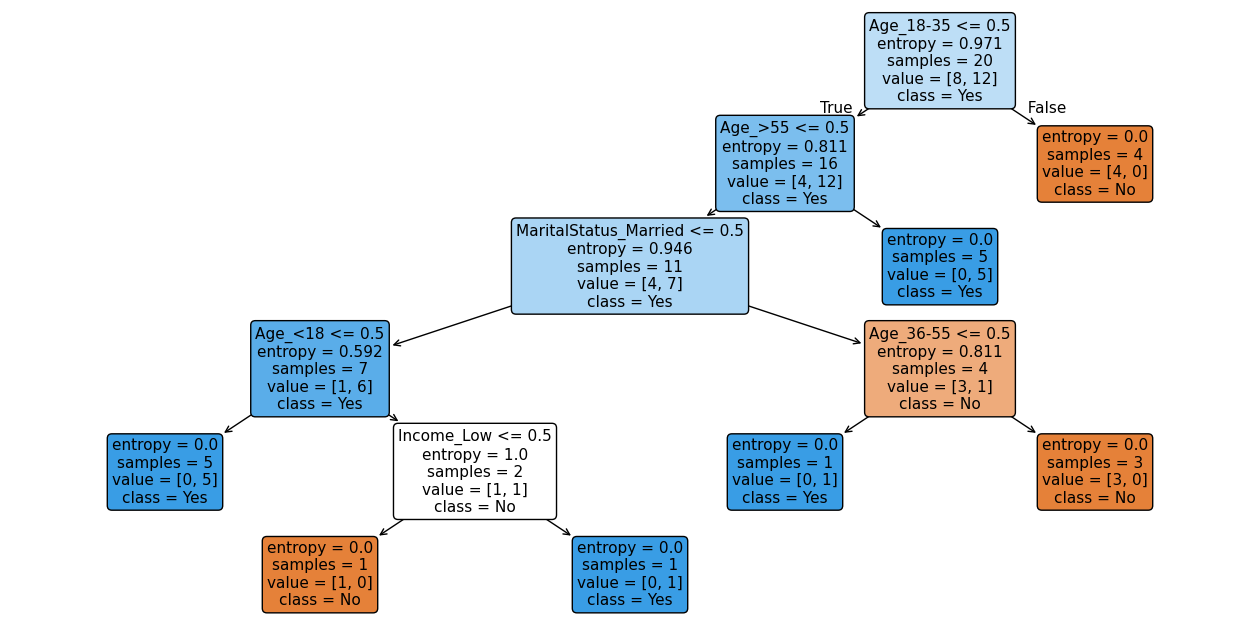

In [109]:
fig, ax = plt.subplots(figsize=(16, 8))
annotations = plot_tree(
    tree,
    feature_names=X.columns,
    class_names=tree.classes_,
    filled=True,
    rounded=True,
    fontsize=11,
    ax=ax
)



plt.show()

In [113]:
sample = pd.DataFrame([['>55', "Master's", 'High', 'Married']], columns=features)
sample_encoded = pd.get_dummies(sample, dtype=int).reindex(columns=X.columns, fill_value=0)

print("Prediction:", tree.predict(sample_encoded)[0])

Prediction: Yes
